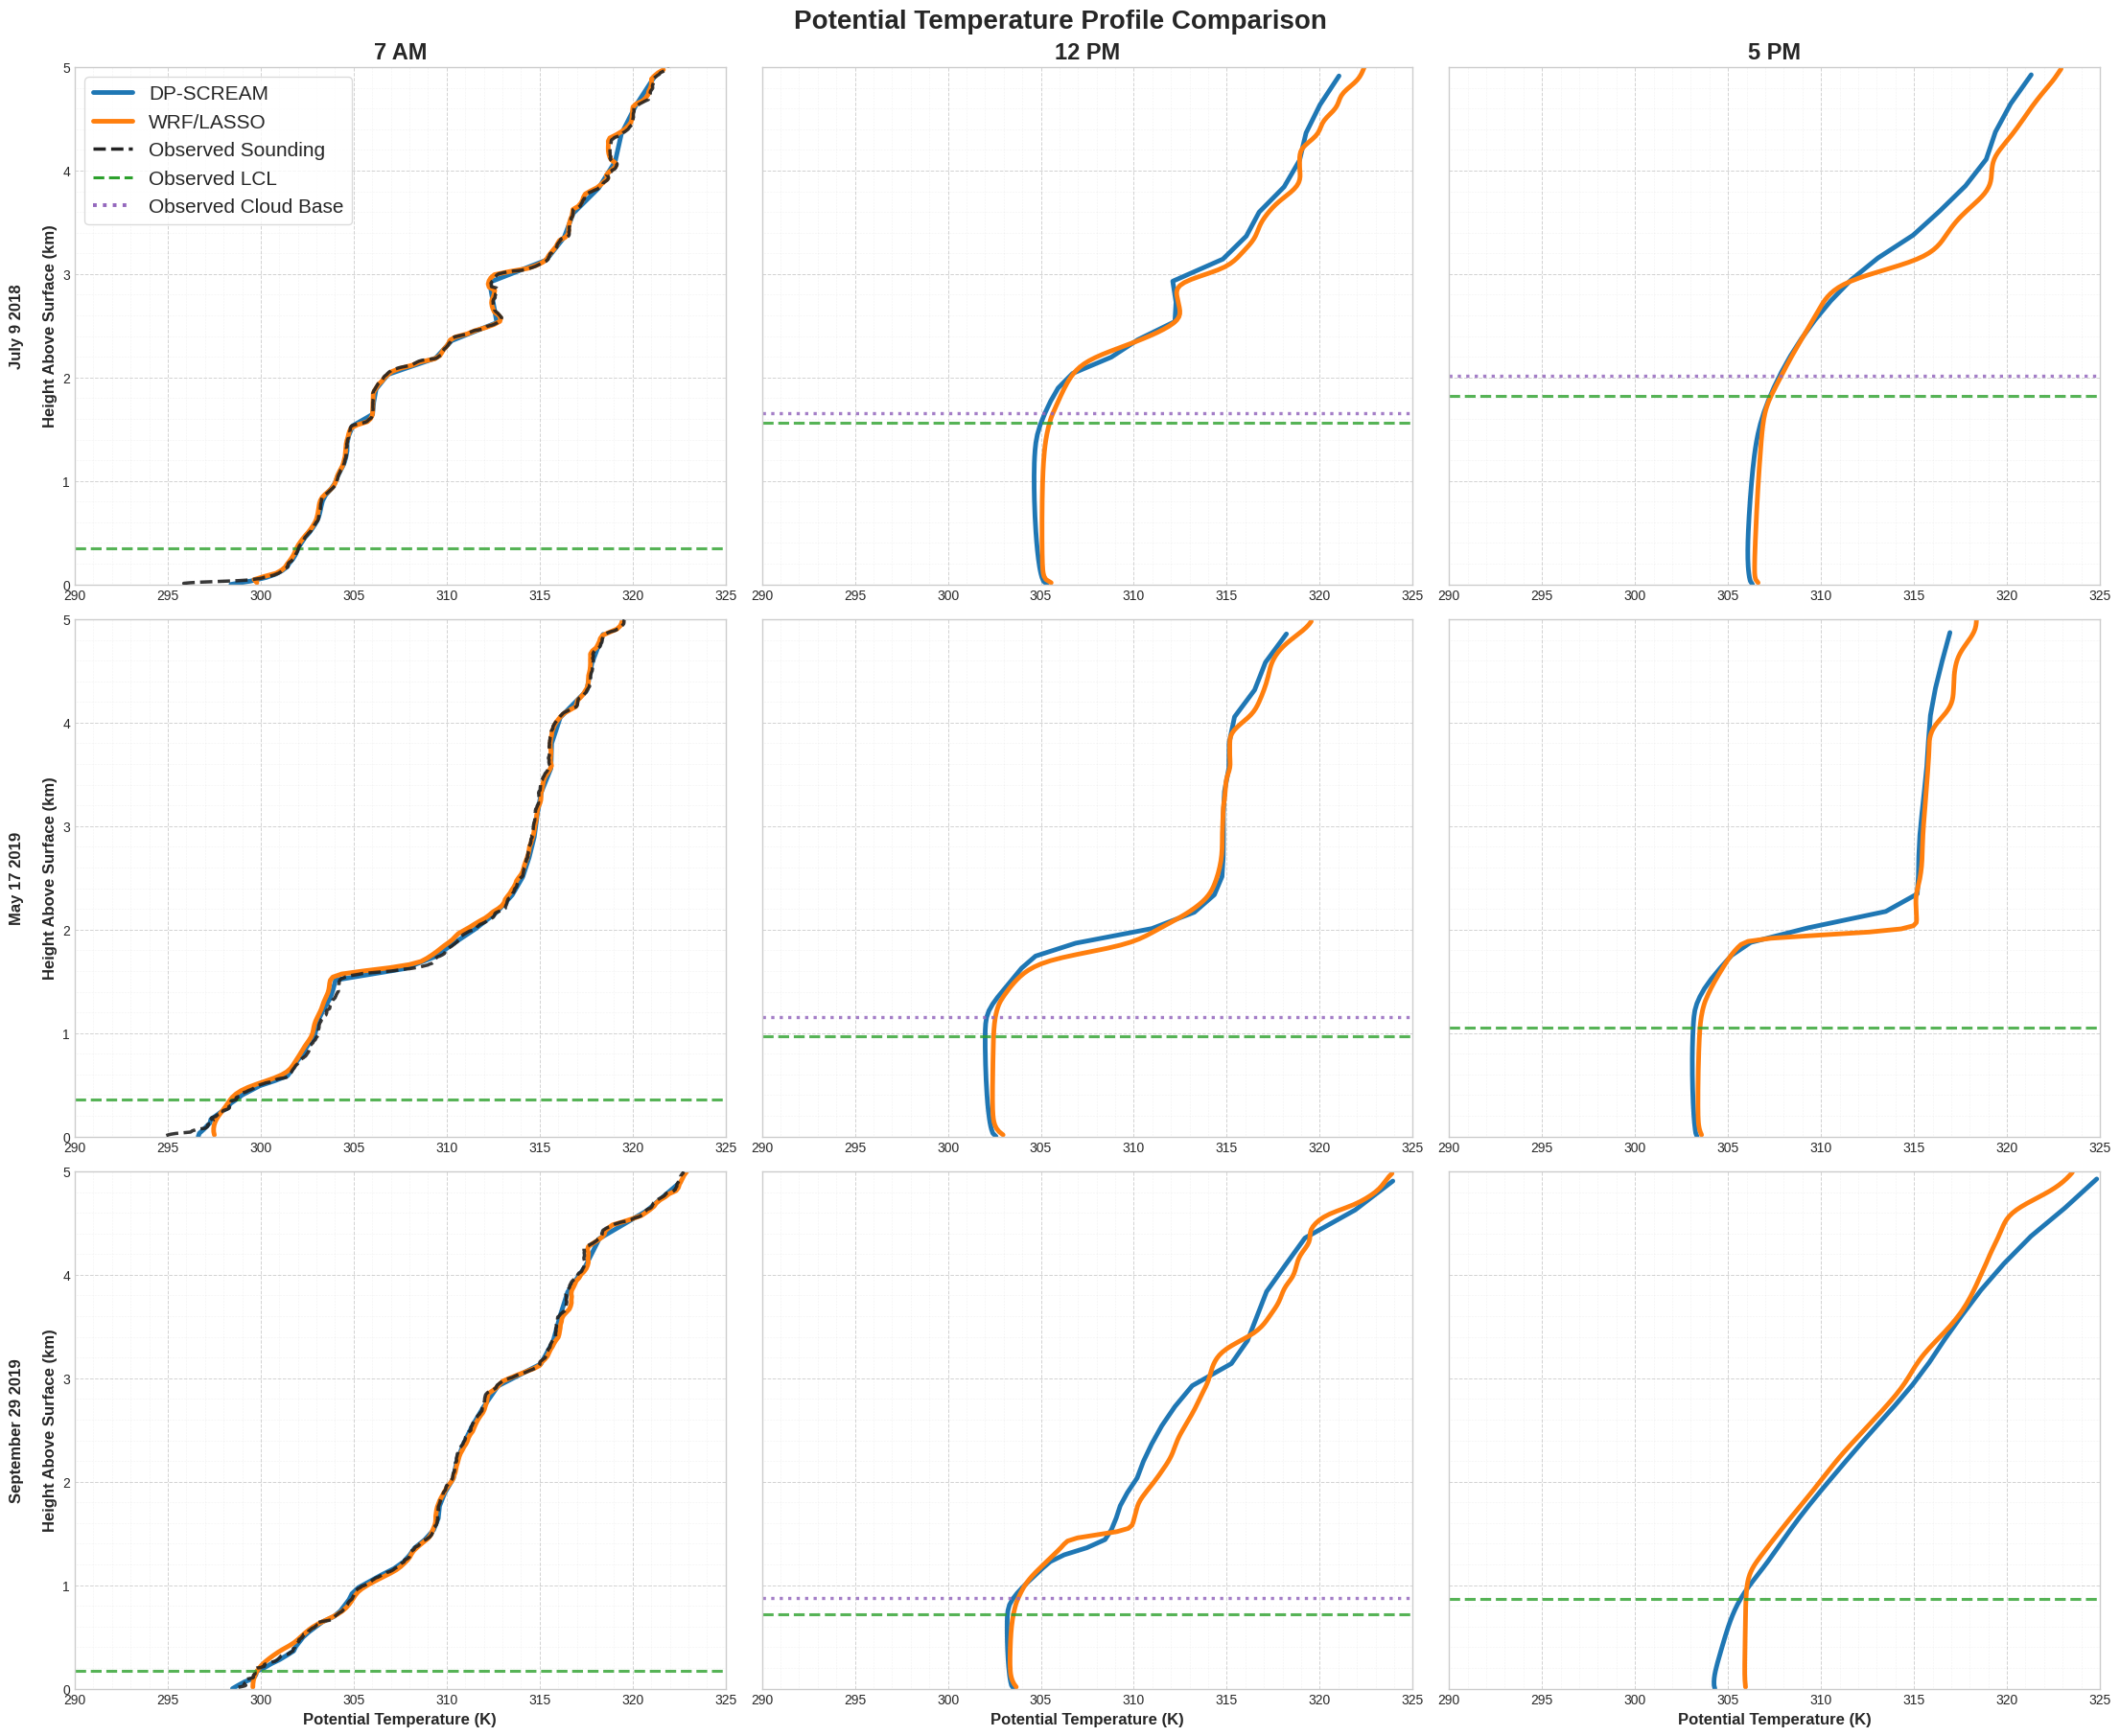

In [29]:
# IMPORTS ************************************************

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from matplotlib.lines import Line2D

# SETTINGS ***********************************************

HEIGHT_LIMIT = 5
THETA_MIN = 290
THETA_MAX = 325

SURFACE_OFFSET = 0.33425546 #(km above sea level)

COLOR_SCREAM = "#1f77b4"
COLOR_WRF = "#ff7f0e"
COLOR_SOUND = "#222222"
COLOR_LCL = "#2ca02c"
COLOR_CB = "#9467bd"

# FIGURE *************************************************

fig, axes = plt.subplots(
    3, 3,
    figsize=(22,18),
    sharey=True,
    constrained_layout=True
)

fig.patch.set_facecolor("white")

# CASES AND FILES *****************************************

files = {
    "2018-07-09": "/data/project/ARM_Summer_School_2026/data/modeling/lasso/20180709/20180709_sgplassoconf_id8/input_sounding",

    "2019-05-17": "/data/project/ARM_Summer_School_2026/data/modeling/lasso/20190517/20190517_sgplassoconf_id4/input_sounding",

    "2019-09-29": "/data/project/ARM_Summer_School_2026/data/modeling/lasso/20190929/20190929_sgplassoconf_id5/input_sounding"
}

days = [
    {
        "date": "2018-07-09",
        "title": "July 9 2018",

        "scream": "/data/project/ARM_Summer_School_2026/data/modeling/dpscream/"
                   "scream_dpxx_LASSO_SGP_2018-07-09.fullfield.AVERAGE.nhours_x1.2018-07-09-43200.nc",

        "wrf": "/data/project/ARM_Summer_School_2026/data/modeling/lasso/20180709/"
               "sgplassodiagconfobsmod8C1.m1/obs_model/"
               "sgplassomod8C1.m1.20180709.120000.nc",

        "diag": "/data/project/ARM_Summer_School_2026/data/modeling/lasso/20180709/"
                "sgplassodiagconfobsmod8C1.m1/obs_model/"
                "sgplassodiagobsmod8C1.m1.20180709.120000.nc"
    },

    {
        "date": "2019-05-17",
        "title": "May 17 2019",

        "scream": "/data/project/ARM_Summer_School_2026/data/modeling/dpscream/"
                   "scream_dpxx_LASSO_SGP_2019-05-17.fullfield.AVERAGE.nhours_x1.2019-05-17-43200.nc",

        "wrf": "/data/project/ARM_Summer_School_2026/data/modeling/lasso/20190517/"
               "sgplassodiagconfobsmod4C1.m1/obs_model/"
               "sgplassomod4C1.m1.20190517.120000.nc",

        "diag": "/data/project/ARM_Summer_School_2026/data/modeling/lasso/20190517/"
                "sgplassodiagconfobsmod4C1.m1/obs_model/"
                "sgplassodiagobsmod4C1.m1.20190517.120000.nc"
    },

    {
        "date": "2019-09-29",
        "title": "September 29 2019",

        "scream": "/data/project/ARM_Summer_School_2026/data/modeling/dpscream/"
                   "scream_dpxx_LASSO_SGP_2019-09-29.fullfield.AVERAGE.nhours_x1.2019-09-29-43200.nc",

        "wrf": "/data/project/ARM_Summer_School_2026/data/modeling/lasso/20190929/"
               "sgplassodiagconfobsmod4C1.m1/obs_model/"
               "sgplassomod4C1.m1.20190929.120000.nc",

        "diag": "/data/project/ARM_Summer_School_2026/data/modeling/lasso/20190929/"
                "sgplassodiagconfobsmod4C1.m1/obs_model/"
                "sgplassodiagobsmod4C1.m1.20190929.120000.nc"
    }
]

times = [
    ("07:00", "7 AM"),
    ("12:00", "12 PM"),
    ("17:00", "5 PM")
]

# PLOTTING ************************************************

for row, day in enumerate(days):

    ds_scream = xr.open_dataset(day["scream"])

    ds_scream = ds_scream.assign_coords(time=ds_scream.time - pd.Timedelta(hours=6))

    theta_scream = ds_scream["PotentialTemperature"].mean(dim="ncol")

    z_scream = (ds_scream["z_mid"].mean(dim="ncol") / 1000) - SURFACE_OFFSET

    ds_wrf = xr.open_dataset(day["wrf"])

    ds_wrf = ds_wrf.assign_coords(time=ds_wrf.time - pd.Timedelta(hours=6))

    theta_wrf = ds_wrf["potential_temp"]

    ds_diag = xr.open_dataset(day["diag"])

    ds_diag = ds_diag.assign_coords(time=ds_diag.time - pd.Timedelta(hours=6))

    sounding = np.loadtxt(
        files[day["date"]],
        skiprows=1
    )

    z_sound = sounding[:,0] / 1000

    theta_sound = sounding[:,1]

    mask_sound = z_sound < 5

    for col, (hour, hour_title) in enumerate(times):

        ax = axes[row, col]

        time_string = f"{day['date']} {hour}"

# DP-SCREAM ***********************************************

        theta_profile_scream = theta_scream.sel(
            time=time_string,
            method="nearest"
        )

        z_profile_scream = z_scream.sel(
            time=time_string,
            method="nearest"
        )

        mask_scream = z_profile_scream < 5

        ax.plot(
            theta_profile_scream.where(mask_scream),
            z_profile_scream.where(mask_scream),
            linewidth=3.5,
            solid_capstyle="round",
            color=COLOR_SCREAM,
            label="DP-SCREAM"
        )

# WRF/LASSO ***********************************************

        theta_profile_wrf = theta_wrf.sel(
            time=time_string,
            method="nearest"
        )

        z_profile_wrf = theta_profile_wrf["height"]

        mask_wrf = z_profile_wrf < 5

        ax.plot(
            theta_profile_wrf.where(mask_wrf),
            z_profile_wrf.where(mask_wrf),
            linewidth=3.5,
            solid_capstyle="round",
            color=COLOR_WRF,
            label="WRF/LASSO"
        )

# OBSERVED SOUNDING ***************************************

        if col == 0:
            ax.plot(
                theta_sound[mask_sound],
                z_sound[mask_sound],
                color=COLOR_SOUND,
                linestyle="--",
                linewidth=2.5,
                solid_capstyle="round",
                alpha=0.9,
                zorder=10,
                label="Observed Sounding"
            )

# LCL AND CLOUD BASE ***************************************

        lcl = ds_diag["lcl"].isel(
            source_type=0
        ).sel(
            time=time_string,
            method="nearest"
        ) / 1000

        cloud_base = ds_diag["cloud_base_height"].isel(
            source_type=0
        ).sel(
            time=time_string,
            method="nearest"
        ) / 1000

        if lcl > 0.05:
            ax.axhline(
                lcl,
                linestyle="--",
                linewidth=2.2,
                color=COLOR_LCL,
                alpha=0.8
            )

        if cloud_base > 0.05:
            ax.axhline(
                cloud_base,
                linestyle=":",
                linewidth=2.4,
                color=COLOR_CB,
                alpha=0.85
            )

# FORMATTING ***********************************************

        ax.set_xlim(THETA_MIN, THETA_MAX)

        ax.set_ylim(0, HEIGHT_LIMIT)

        ax.minorticks_on()

        ax.grid(
            which="major",
            linestyle="--",
            linewidth=0.7,
            alpha=0.35,
            color="gray"
        )

        ax.grid(
            which="minor",
            linestyle=":",
            linewidth=0.4,
            alpha=0.2,
            color="gray"
        )
        
        ax.tick_params(
            labelsize=10
        )

        if row == 0:
            ax.set_title(
                hour_title,
                fontsize=17,
                weight="semibold"
            )

        if col == 0:
            ax.set_ylabel(
                f"{day['title']}\n\nHeight Above Surface (km)",
                fontsize=12,
                weight="bold"
            )

        if row == 2:
            ax.set_xlabel(
                "Potential Temperature (K)",
                fontsize=12,
                weight="bold"
            )

# LEGEND **************************************************

legend_lines = [
    Line2D([0], [0], color=COLOR_SCREAM, lw=3.5),
    Line2D([0], [0], color=COLOR_WRF, lw=3.5),
    Line2D([0], [0], color=COLOR_SOUND, lw=2.5, linestyle='--'),
    Line2D([0], [0], color=COLOR_LCL, lw=2.2, linestyle='--'),
    Line2D([0], [0], color=COLOR_CB, lw=2.8, linestyle=':')
]

axes[0,0].legend(
    legend_lines,
    [
        "DP-SCREAM",
        "WRF/LASSO",
        "Observed Sounding",
        "Observed LCL",
        "Observed Cloud Base"
    ],
    fontsize=15,
    frameon=True,
    facecolor="white",
    edgecolor="lightgray"
)

# TITLE AND FIGURE *****************************************

fig.suptitle(
    "Potential Temperature Profile Comparison",
    fontsize=20,
    weight="bold"
)

plt.show()